# 📈 Portfolio Optimization with Modern Portfolio Theory (MPT)

Welcome! In this project, we’ll build an optimized stock portfolio using **Modern Portfolio Theory**.

This notebook is designed for beginners, with step-by-step explanations.

## 🎯 Objective
We aim to:
- Download stock data
- Calculate returns and risk
- Simulate portfolios
- Identify the best one using the **Sharpe Ratio**

In [53]:
pip install numpy pandas matplotlib yfinance

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

%matplotlib inline

## 💼 Step 1: Choose Your Stocks

In [55]:
stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
print(stocks)

['AAPL', 'MSFT', 'GOOGL', 'AMZN']


## 📥 Step 2: Download Historical Data

In [59]:
data = yf.download(stocks , start="2025-01-01", end = "2025-12-31")
print(data)

[*********************100%***********************]  4 of 4 completed

Price            Close                                            High  \
Ticker            AAPL        AMZN       GOOGL        MSFT        AAPL   
Date                                                                     
2025-01-02  242.525162  220.220001  188.558258  414.568604  247.746638   
2025-01-03  242.037811  224.190002  190.907410  419.292908  242.853348   
2025-01-06  243.668915  227.610001  195.964035  423.749786  245.986258   
2025-01-07  240.894073  222.110001  194.590393  418.322296  244.215924   
2025-01-08  241.381409  222.130005  193.057480  420.491272  242.385931   
...                ...         ...         ...         ...         ...   
2025-12-23  272.105377  232.139999  314.128876  485.741333  272.245261   
2025-12-24  273.554016  232.380005  313.869049  486.908630  275.172497   
2025-12-26  273.144409  232.520004  313.289459  486.599365  275.112569   
2025-12-29  273.504089  232.070007  313.339417  485.990753  274.103504   
2025-12-30  272.824707  232.529999  31

## 🔁 Step 3: Calculate Daily Returns

In [43]:
returns = data["Close"].pct_change()
print(returns)

Ticker          AAPL      AMZN     GOOGL      MSFT
Date                                              
2025-01-02       NaN       NaN       NaN       NaN
2025-01-03 -0.002009  0.018027  0.012458  0.011396
2025-01-06  0.006739  0.015255  0.026487  0.010630
2025-01-07 -0.011388 -0.024164 -0.007010 -0.012808
2025-01-08  0.002023  0.000090 -0.007878  0.005185
...              ...       ...       ...       ...
2025-12-23  0.005130  0.016241  0.014752  0.003980
2025-12-24  0.005324  0.001034 -0.000827  0.002403
2025-12-26 -0.001497  0.000602 -0.001847 -0.000635
2025-12-29  0.001317 -0.001935  0.000159 -0.001251
2025-12-30 -0.002484  0.001982  0.000925  0.000780

[249 rows x 4 columns]


## 📊 Step 4: Calculate Mean Returns and Covariance

In [44]:
mean_returns = returns.mean()
print(mean_returns)

Ticker
AAPL     0.000681
AMZN     0.000454
GOOGL    0.002261
MSFT     0.000760
dtype: float64


In [45]:
covariance_matrix = returns.cov()
print(covariance_matrix)

Ticker      AAPL      AMZN     GOOGL      MSFT
Ticker                                        
AAPL    0.000420  0.000255  0.000209  0.000153
AMZN    0.000255  0.000474  0.000242  0.000195
GOOGL   0.000209  0.000242  0.000418  0.000133
MSFT    0.000153  0.000195  0.000133  0.000235


## ⚙️ Step 5: Define Portfolio Performance Functions

In [48]:
num_portfolios = 100

results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    
    # Portfolio Return
    portfolio_return = np.sum(weights * mean_returns)
    
    # Portfolio Risk
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix, weights)))
    
    results[0,i] = portfolio_std
    results[1,i] = portfolio_return
    results[2,i] = results[1,i] / results[0,i]  # Sharpe Ratio

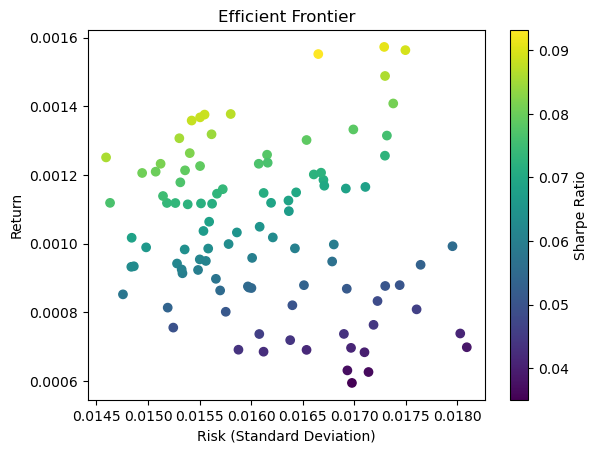

In [49]:
plt.figure()
plt.scatter(results[0,:], results[1,:], c=results[2,:])
plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.show()

## 🚧 Step 6: Optimization Constraints

## 🚀 Step 7: Optimize the Portfolio

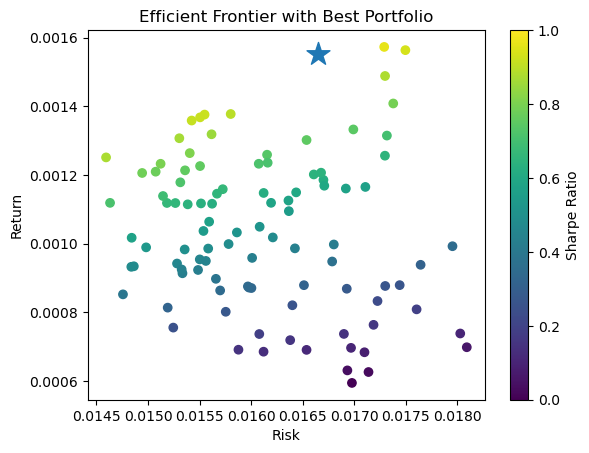

Best Return: 0.0015518793246629837
Best Risk: 0.016651951123950546


In [60]:
max_sharpe_idx = np.argmax(results[2])
best_risk = results[0, max_sharpe_idx]
best_return = results[1, max_sharpe_idx]

plt.figure()
plt.scatter(results[0,:], results[1,:], c=results[2,:])
plt.scatter(results[0,max_sharpe_idx], results[1,max_sharpe_idx], marker='*', s=300)

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier with Best Portfolio")
plt.colorbar(label="Sharpe Ratio")
plt.show()

print("Best Return:", best_return)
print("Best Risk:", best_risk)

## ✅ Step 8: Show Optimized Portfolio

In [62]:

print(f"\nExpected Annual Return: ",best_return)
print(f"Annual Volatility:", results[0,i])
print(f"Sharpe Ratio:", results[2,i])


Expected Annual Return:  0.0015518793246629837
Annual Volatility: 0.017291562657845136
Sharpe Ratio: 0.09095056308477832


## 🧠 Conclusion

You just created an optimized portfolio using **Modern Portfolio Theory**!

You learned to:
- Download and analyze stock data
- Calculate return & risk
- Maximize the Sharpe Ratio 🚀

Try it with different stocks or time ranges for more insights.